In [3]:
import pandas as pd
import numpy as np
import duckdb


from sklearn.model_selection import train_test_split


WAREHOUSE_DB = r"C:\Users\howar\OneDrive\Documents\BU Mod2\699 pt2\Real Estate\warehouse\realestate_warehouse.duckdb"
GOLD_DB = r"C:\Users\howar\OneDrive\Documents\BU Mod2\699 pt2\Real Estate\gold\realestate_gold.duckdb"

con = duckdb.connect(GOLD_DB)

con.execute(f"""
ATTACH '{WAREHOUSE_DB}' AS wh;
""")

In [4]:
con.execute("""

UPDATE model_property_features_v8 AS v
SET property_age =
    CASE
        WHEN a.yr_impr IS NULL OR a.yr_impr <= 0 THEN NULL
        WHEN a.yr_impr > EXTRACT(YEAR FROM v.snapshot_date) THEN 0
        ELSE EXTRACT(YEAR FROM v.snapshot_date) - a.yr_impr
    END
FROM property_anchor AS a
WHERE v.acct = a.acct;""").df()

,Count
0,257043


In [5]:
con.execute("""SELECT
    MIN(property_age),
    MAX(property_age),
    COUNT(*) FILTER (WHERE property_age < 0) AS negatives
FROM model_property_features_v8;""").df()

,min(property_age),max(property_age),negatives
0,0,176,0


In [6]:
con.execute("""SELECT
    COUNT(*) AS total_rows,
    COUNT(*) FILTER (WHERE months_since_last_deed IS NULL) AS null_months_since_last_deed,
    COUNT(*) FILTER (WHERE months_since_last_civil IS NULL) AS null_months_since_last_civil,
    COUNT(*) FILTER (WHERE cnt_311_total_12mo IS NULL) AS null_cnt_311_total_12mo,
    COUNT(*) FILTER (WHERE property_age IS NULL) AS null_property_age,
    COUNT(*) FILTER (WHERE years_owned IS NULL) AS null_years_owned
FROM model_property_features_v8;""").df()

,total_rows,null_months_since_last_deed,null_months_since_last_civil,null_cnt_311_total_12mo,null_property_age,null_years_owned
0,257043,183531,253299,0,0,0


In [7]:
con.execute("""SELECT
    sold_next_12mo,
    COUNT(*) AS row_count
FROM model_property_features_v8
GROUP BY sold_next_12mo
ORDER BY sold_next_12mo;""").df()

,sold_next_12mo,row_count
0,0,233157
1,1,23886


In [8]:
cols_to_drop = [
    "owner_entity_flag",
    "absentee_owner_flag",
    "distress_score",
    "lien_absentee",
    "distress_x_tenure",
    "distress_intensity_v3",
    "distress_bucket_v3"
]

for col in cols_to_drop:
    try:
        con.execute(f"""
        ALTER TABLE model_property_features_v8
        DROP COLUMN {col}
        """)
        print(f"Dropped: {col}")
    except Exception as e:
        print(f"Skipping {col} (may not exist):", e)

Skipping owner_entity_flag (may not exist): Binder Error: Table "model_property_features_v8" does not have a column with name "owner_entity_flag"

Did you mean: "debt_entity"
Skipping absentee_owner_flag (may not exist): Binder Error: Table "model_property_features_v8" does not have a column with name "absentee_owner_flag"

Did you mean: "years_owned"
Skipping distress_score (may not exist): Binder Error: Table "model_property_features_v8" does not have a column with name "distress_score"

Did you mean: "liens_24mo"
Skipping lien_absentee (may not exist): Binder Error: Table "model_property_features_v8" does not have a column with name "lien_absentee"

Did you mean: "recent_deed"
Skipping distress_x_tenure (may not exist): Binder Error: Table "model_property_features_v8" does not have a column with name "distress_x_tenure"

Did you mean: "years_owned"
Skipping distress_intensity_v3 (may not exist): Binder Error: Table "model_property_features_v8" does not have a column with name "distr

In [9]:


df_model = con.execute("""
SELECT *
FROM model_property_features_v8
""").df()

In [10]:
con.execute("""DESCRIBE model_property_features_v8""").df()

,column_name,column_type,null,key,default,extra
0,acct,VARCHAR,YES,None,None,None
1,snapshot_date,TIMESTAMP,YES,None,None,None
2,years_owned,BIGINT,YES,None,None,None
3,sold_next_6mo,INTEGER,YES,None,None,None
4,sold_next_12mo,INTEGER,YES,None,None,None
5,sold_next_24mo,INTEGER,YES,None,None,None
6,building_area,BIGINT,YES,None,None,None
7,property_age,BIGINT,YES,None,None,None
8,deed_24mo,BIGINT,YES,None,None,None
9,liens_24mo,DOUBLE,YES,None,None,None


In [11]:
print(df_model.shape)
print(df_model.columns)

(257043, 33)
Index(['acct', 'snapshot_date', 'years_owned', 'sold_next_6mo',
       'sold_next_12mo', 'sold_next_24mo', 'building_area', 'property_age',
       'deed_24mo', 'liens_24mo', 'debt_24mo', 'cnt_311_total_12mo',
       'months_since_last_deed', 'months_since_last_civil', 'debt_entity',
       'cnt_311_property_maintenance', 'cnt_311_vehicle_issues',
       'cnt_311_building_standards', 'cnt_311_nuisance',
       'cnt_311_total_distress', 'recent_civil', 'recent_deed',
       'neighborhood_code', 'probate_event_count_strict', 'has_probate_strict',
       'first_probate_date_strict', 'last_probate_date_strict',
       'days_since_probate_strict', 'probate_strict_last_12mo',
       'probate_strict_last_24mo', 'probate_strict_last_30mo',
       'probate_strict_last_36mo', 'probate_strict_last_40mo'],
      dtype='object')


In [12]:
df_modelacct = con.execute("""
Select*
From model_property_features_v8""").df()

df_modelacct.head(25)

,acct,snapshot_date,years_owned,sold_next_6mo,sold_next_12mo,sold_next_24mo,building_area,property_age,deed_24mo,liens_24mo,...,probate_event_count_strict,has_probate_strict,first_probate_date_strict,last_probate_date_strict,days_since_probate_strict,probate_strict_last_12mo,probate_strict_last_24mo,probate_strict_last_30mo,probate_strict_last_36mo,probate_strict_last_40mo
0,0923300000035,2022-01-01,6,0,0,0,1435,54,0,0.0,...,0,0,NaT,NaT,<NA>,0,0,0,0,0
1,0923310000009,2025-01-01,3,0,0,0,1203,57,0,0.0,...,0,0,NaT,NaT,<NA>,0,0,0,0,0
2,0923310000012,2019-01-01,1,0,0,0,1089,51,0,0.0,...,0,0,NaT,NaT,<NA>,0,0,0,0,0
3,0923310000018,2020-01-01,3,0,0,0,1008,52,0,0.0,...,0,0,NaT,NaT,<NA>,0,0,0,0,0
4,0923310000024,2017-01-01,2,0,0,0,1518,49,0,0.0,...,0,0,NaT,NaT,<NA>,0,0,0,0,0
5,0923310000030,2021-01-01,4,0,0,0,1368,53,2,0.0,...,0,0,NaT,NaT,<NA>,0,0,0,0,0
6,0923320000002,2018-01-01,2,0,0,0,1089,50,0,0.0,...,0,0,NaT,NaT,<NA>,0,0,0,0,0
7,0923320000009,2025-01-01,9,0,0,0,1008,57,0,0.0,...,0,0,NaT,NaT,<NA>,0,0,0,0,0
8,0923330000017,2020-01-01,3,0,0,0,1068,50,5,0.0,...,0,0,NaT,NaT,<NA>,0,0,0,0,0
9,0923330000026,2025-01-01,8,0,0,0,1938,55,0,0.0,...,0,0,NaT,NaT,<NA>,0,0,0,0,0


In [13]:
drop_cols = [
    'acct',
    'snapshot_date',
    'first_probate_date_strict',
    'last_probate_date_strict'
]

df_model = df_model.drop(columns=drop_cols)

In [14]:
probate_features = [
    'probate_strict_last_24mo',
    'days_since_probate_strict'
]

In [15]:
print(df_model.shape)
print(df_model.columns)

(257043, 29)
Index(['years_owned', 'sold_next_6mo', 'sold_next_12mo', 'sold_next_24mo',
       'building_area', 'property_age', 'deed_24mo', 'liens_24mo', 'debt_24mo',
       'cnt_311_total_12mo', 'months_since_last_deed',
       'months_since_last_civil', 'debt_entity',
       'cnt_311_property_maintenance', 'cnt_311_vehicle_issues',
       'cnt_311_building_standards', 'cnt_311_nuisance',
       'cnt_311_total_distress', 'recent_civil', 'recent_deed',
       'neighborhood_code', 'probate_event_count_strict', 'has_probate_strict',
       'days_since_probate_strict', 'probate_strict_last_12mo',
       'probate_strict_last_24mo', 'probate_strict_last_30mo',
       'probate_strict_last_36mo', 'probate_strict_last_40mo'],
      dtype='object')


In [16]:
df_model.head(5)

,years_owned,sold_next_6mo,sold_next_12mo,sold_next_24mo,building_area,property_age,deed_24mo,liens_24mo,debt_24mo,cnt_311_total_12mo,...,recent_deed,neighborhood_code,probate_event_count_strict,has_probate_strict,days_since_probate_strict,probate_strict_last_12mo,probate_strict_last_24mo,probate_strict_last_30mo,probate_strict_last_36mo,probate_strict_last_40mo
0,6,0,0,0,1435,54,0,0.0,0.0,0,...,0,793.0,0,0,<NA>,0,0,0,0,0
1,3,0,0,0,1203,57,0,0.0,0.0,0,...,0,793.0,0,0,<NA>,0,0,0,0,0
2,1,0,0,0,1089,51,0,0.0,1.0,0,...,0,793.0,0,0,<NA>,0,0,0,0,0
3,3,0,0,0,1008,52,0,0.0,0.0,0,...,0,793.0,0,0,<NA>,0,0,0,0,0
4,2,0,0,0,1518,49,0,0.0,0.0,0,...,0,793.0,0,0,<NA>,0,0,0,0,0


In [17]:
df_model.shape

(257043, 29)

In [18]:
df_model = df_model[(df_model["building_area"] > 900) & (df_model["building_area"] <= 4000)]

In [19]:
df_model.shape

(238175, 29)

In [20]:
df_model["has_probate_strict"].sum()

np.int64(730)

In [21]:
df_model["cnt_311_total_12mo"].sum()

np.int64(93251)

In [22]:
df_model.head(100)

,years_owned,sold_next_6mo,sold_next_12mo,sold_next_24mo,building_area,property_age,deed_24mo,liens_24mo,debt_24mo,cnt_311_total_12mo,...,recent_deed,neighborhood_code,probate_event_count_strict,has_probate_strict,days_since_probate_strict,probate_strict_last_12mo,probate_strict_last_24mo,probate_strict_last_30mo,probate_strict_last_36mo,probate_strict_last_40mo
0,6,0,0,0,1435,54,0,0.0,0.0,0,...,0,793.0,0,0,<NA>,0,0,0,0,0
1,3,0,0,0,1203,57,0,0.0,0.0,0,...,0,793.0,0,0,<NA>,0,0,0,0,0
2,1,0,0,0,1089,51,0,0.0,1.0,0,...,0,793.0,0,0,<NA>,0,0,0,0,0
3,3,0,0,0,1008,52,0,0.0,0.0,0,...,0,793.0,0,0,<NA>,0,0,0,0,0
4,2,0,0,0,1518,49,0,0.0,0.0,0,...,0,793.0,0,0,<NA>,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99,1,0,0,0,2094,65,0,0.0,0.0,0,...,0,7492.0,0,0,<NA>,0,0,0,0,0
100,3,0,0,0,2934,65,0,0.0,0.0,0,...,0,7492.0,0,0,<NA>,0,0,0,0,0
101,5,0,0,1,2019,61,0,0.0,0.0,0,...,0,7492.0,0,0,<NA>,0,0,0,0,0
102,2,0,0,0,1821,61,0,0.0,0.0,0,...,0,7492.0,0,0,<NA>,0,0,0,0,0


In [23]:
#how fast a probate tuns into sale

# Load data
df_model = con.execute("""
SELECT *
FROM model_property_features_v8
""").df()

# Filter to probate properties only
df = df_model[df_model["has_probate_strict"] == 1].copy()

# Ensure numeric
df["days_since_probate_strict"] = pd.to_numeric(
    df["days_since_probate_strict"], errors="coerce"
)

df["probate_recency_bucket"] = pd.cut(
    df["days_since_probate_strict"],
    bins=[-1, 180, 365, 730, 1095, 10000],
    labels=["0-6mo", "6-12mo", "12-24mo", "24-36mo", "36mo+"]
)

summary = (
    df.groupby("probate_recency_bucket")
      .agg(
          properties=("acct", "count"),
          sales=("sold_next_12mo", "sum"),
          sale_rate_pct=("sold_next_12mo", lambda x: round(100 * x.mean(), 2))
      )
      .reset_index()
)

summary

C:\Users\howar\AppData\Local\Temp\ipykernel_23576\3219965654.py:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("probate_recency_bucket")


,probate_recency_bucket,properties,sales,sale_rate_pct
0,0-6mo,33,9,27.27
1,6-12mo,71,13,18.31
2,12-24mo,140,16,11.43
3,24-36mo,121,12,9.92
4,36mo+,400,26,6.50


In [24]:
print(df_model.shape)
print(df_model.columns)

(257043, 33)
Index(['acct', 'snapshot_date', 'years_owned', 'sold_next_6mo',
       'sold_next_12mo', 'sold_next_24mo', 'building_area', 'property_age',
       'deed_24mo', 'liens_24mo', 'debt_24mo', 'cnt_311_total_12mo',
       'months_since_last_deed', 'months_since_last_civil', 'debt_entity',
       'cnt_311_property_maintenance', 'cnt_311_vehicle_issues',
       'cnt_311_building_standards', 'cnt_311_nuisance',
       'cnt_311_total_distress', 'recent_civil', 'recent_deed',
       'neighborhood_code', 'probate_event_count_strict', 'has_probate_strict',
       'first_probate_date_strict', 'last_probate_date_strict',
       'days_since_probate_strict', 'probate_strict_last_12mo',
       'probate_strict_last_24mo', 'probate_strict_last_30mo',
       'probate_strict_last_36mo', 'probate_strict_last_40mo'],
      dtype='object')


In [25]:
import pandas as pd
import numpy as np

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1400)

df = con.execute("SELECT * FROM model_property_features_v8").df()

# Outcome
df["sold_next_12mo"] = pd.to_numeric(df["sold_next_12mo"], errors="coerce").fillna(0)

# Binary flags for each distress/probate type
df["probate_12mo"] = df["probate_strict_last_12mo"].fillna(0).eq(1)
df["maint_12mo"] = df["cnt_311_property_maintenance"].fillna(0).gt(0)
df["vehicle_12mo"] = df["cnt_311_vehicle_issues"].fillna(0).gt(0)
df["building_12mo"] = df["cnt_311_building_standards"].fillna(0).gt(0)
df["nuisance_12mo"] = df["cnt_311_nuisance"].fillna(0).gt(0)
df["liens_24mo_flag"] = df["liens_24mo"].fillna(0).gt(0)
df["debt_24mo_flag"] = df["debt_24mo"].fillna(0).gt(0)

# Create clean Yes/No labels for grouping
df["probate_flag"] = np.where(df["probate_12mo"], "Yes", "No")
df["maint_flag"] = np.where(df["maint_12mo"], "Yes", "No")
df["vehicle_flag"] = np.where(df["vehicle_12mo"], "Yes", "No")
df["building_flag"] = np.where(df["building_12mo"], "Yes", "No")
df["nuisance_flag"] = np.where(df["nuisance_12mo"], "Yes", "No")
df["liens_flag"] = np.where(df["liens_24mo_flag"], "Yes", "No")
df["debt_flag"] = np.where(df["debt_24mo_flag"], "Yes", "No")

# Group by all itemized event types
result = (
    df.groupby(
        [
            "probate_flag",
            "maint_flag",
            "vehicle_flag",
            "building_flag",
            "nuisance_flag",
            "liens_flag",
            "debt_flag",
        ],
        dropna=False
    )
    .agg(
        properties=("acct", "count"),
        sales=("sold_next_12mo", "sum"),
        sale_rate=("sold_next_12mo", "mean"),
    )
    .reset_index()
)

result["sale_rate"] = (result["sale_rate"] * 100).round(2)

# Optional: sort so the heavier-distress combos rise to the top
result = result.sort_values(
    by=[
        "probate_flag",
        "maint_flag",
        "vehicle_flag",
        "building_flag",
        "nuisance_flag",
        "liens_flag",
        "debt_flag",
    ],
    ascending=False
).reset_index(drop=True)

print(result)

   probate_flag maint_flag vehicle_flag building_flag nuisance_flag liens_flag debt_flag  properties  sales  sale_rate
0           Yes        Yes           No            No           Yes         No        No           1      0       0.00
1           Yes         No           No           Yes            No         No        No           1      0       0.00
2           Yes         No           No            No            No         No        No         102     22      21.57
3            No        Yes          Yes           Yes           Yes         No        No           8      1      12.50
4            No        Yes          Yes           Yes            No        Yes        No           5      0       0.00
5            No        Yes          Yes           Yes            No         No        No          32      1       3.12
6            No        Yes          Yes            No           Yes         No        No          20      0       0.00
7            No        Yes          Yes         

In [26]:
import pandas as pd
import numpy as np

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1400)

df = con.execute("SELECT * FROM model_property_features_v8").df()

df["sold_next_12mo"] = pd.to_numeric(df["sold_next_12mo"], errors="coerce").fillna(0)

event_flags = {
    "Probate 12mo": df["probate_strict_last_12mo"].fillna(0).eq(1),
    "311 Property Maintenance": df["cnt_311_property_maintenance"].fillna(0).gt(0),
    "311 Vehicle Issues": df["cnt_311_vehicle_issues"].fillna(0).gt(0),
    "311 Building Standards": df["cnt_311_building_standards"].fillna(0).gt(0),
    "311 Nuisance": df["cnt_311_nuisance"].fillna(0).gt(0),
    "Liens 24mo": df["liens_24mo"].fillna(0).gt(0),
    "Debt 24mo": df["debt_24mo"].fillna(0).gt(0),
}

rows = []

for event_name, mask in event_flags.items():
    temp = df.copy()
    temp["event_present"] = np.where(mask, "Yes", "No")

    summary = (
        temp.groupby("event_present", dropna=False)
            .agg(
                properties=("acct", "count"),
                sales=("sold_next_12mo", "sum"),
                sale_rate=("sold_next_12mo", "mean")
            )
            .reset_index()
    )

    summary["sale_rate"] = (summary["sale_rate"] * 100).round(2)
    summary["event_type"] = event_name
    rows.append(summary)

result_itemized = pd.concat(rows, ignore_index=True)
result_itemized = result_itemized[["event_type", "event_present", "properties", "sales", "sale_rate"]]
result_itemized = result_itemized.sort_values(["event_type", "event_present"]).reset_index(drop=True)

print(result_itemized)

                  event_type event_present  properties  sales  sale_rate
0     311 Building Standards            No      255287  23667       9.27
1     311 Building Standards           Yes        1756    219      12.47
2               311 Nuisance            No      254988  23629       9.27
3               311 Nuisance           Yes        2055    257      12.51
4   311 Property Maintenance            No      251079  23236       9.25
5   311 Property Maintenance           Yes        5964    650      10.90
6         311 Vehicle Issues            No      256506  23840       9.29
7         311 Vehicle Issues           Yes         537     46       8.57
8                  Debt 24mo            No      255633  23754       9.29
9                  Debt 24mo           Yes        1410    132       9.36
10                Liens 24mo            No      255726  23750       9.29
11                Liens 24mo           Yes        1317    136      10.33
12              Probate 12mo            No      256

In [27]:
# Baseline of events occuring and sale within the next 12 months
baseline_rate = df["sold_next_12mo"].mean()
print("Baseline sale rate:", round(baseline_rate * 100, 2), "%")

# Add metrics to table
result_itemized["sale_rate_pct"] = (result_itemized["sale_rate"] * 100).round(2)
result_itemized["baseline_rate_pct"] = round(baseline_rate * 100, 2)
result_itemized["lift_vs_baseline"] = (result_itemized["sale_rate"] / baseline_rate).round(2)

# Print full table
print(
    result_itemized.sort_values("lift_vs_baseline", ascending=False)
)

Baseline sale rate: 9.29 %
                  event_type event_present  properties  sales  sale_rate  sale_rate_pct  baseline_rate_pct  lift_vs_baseline
13              Probate 12mo           Yes         104     22      21.15         2115.0               9.29            227.60
3               311 Nuisance           Yes        2055    257      12.51         1251.0               9.29            134.62
1     311 Building Standards           Yes        1756    219      12.47         1247.0               9.29            134.19
5   311 Property Maintenance           Yes        5964    650      10.90         1090.0               9.29            117.30
11                Liens 24mo           Yes        1317    136      10.33         1033.0               9.29            111.16
9                  Debt 24mo           Yes        1410    132       9.36          936.0               9.29            100.73
10                Liens 24mo            No      255726  23750       9.29          929.0           

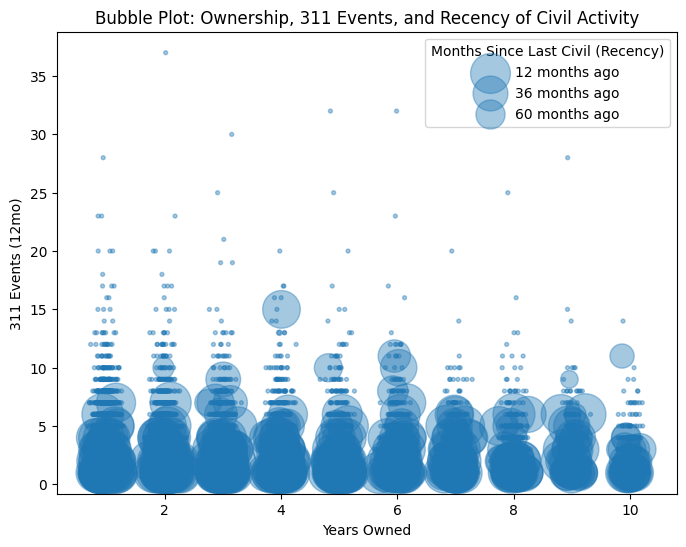

In [28]:
import matplotlib.pyplot as plt
import numpy as np

# Filter to reduce noise
df_filtered = df[df['cnt_311_total_12mo'] > 0].copy()

# Jitter x-axis (fix vertical stacking)
x_jitter = df_filtered['years_owned'] + np.random.normal(0, 0.1, len(df_filtered))

# Handle missing + invert scale (recent civil = bigger bubbles)
months = df_filtered['months_since_last_civil']
max_val = months.max()

months_filled = months.fillna(max_val)

sizes = (max_val - months_filled + 1) * 8

# Plot
plt.figure(figsize=(8,6))
plt.scatter(
    x_jitter,
    df_filtered['cnt_311_total_12mo'],
    s=sizes,
    color='tab:blue',
    alpha=0.4
)

# ---- Legend (must match inverted logic) ----
for m in [12, 36, 60]:
    legend_size = (max_val - m + 1) * 8
    plt.scatter(
        [], [],
        s=legend_size,
        color='tab:blue',
        alpha=0.4,
        label=f"{m} months ago"
    )

plt.xlabel("Years Owned")
plt.ylabel("311 Events (12mo)")
plt.title("Bubble Plot: Ownership, 311 Events, and Recency of Civil Activity")

plt.legend(title="Months Since Last Civil (Recency)", loc='upper right')

plt.show()

“The bubble plot illustrates the relationship between ownership duration, recent 311 distress events, and the recency of civil legal activity. Most properties exhibit low levels of distress, with 311 event counts concentrated below five. Larger bubbles, representing more recent civil activity, are relatively sparse but appear more frequently among properties with moderate ownership durations. This suggests that legal distress signals are infrequent but may coincide with elevated physical distress indicators, highlighting a subset of properties with higher likelihood of ownership transition.”

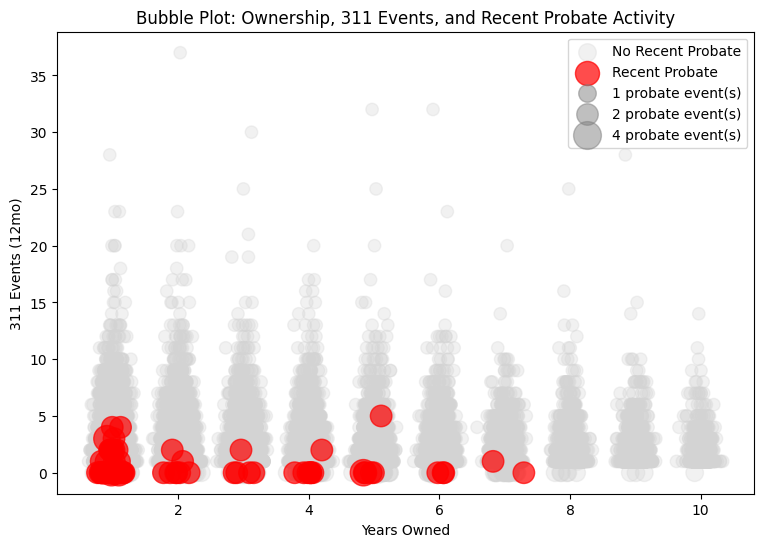

In [29]:
import matplotlib.pyplot as plt
import numpy as np

# Keep rows with at least some distress or probate signal
df_probate = df[
    (df['cnt_311_total_12mo'] > 0) |
    (df['has_probate_strict'] == 1)
].copy()

# Split into groups
df_no_probate = df_probate[df_probate['probate_strict_last_12mo'] == 0].copy()
df_yes_probate = df_probate[df_probate['probate_strict_last_12mo'] == 1].copy()

plt.figure(figsize=(9, 6))

# Non-probate points in background
plt.scatter(
    df_no_probate['years_owned'] + np.random.normal(0, 0.1, len(df_no_probate)),
    df_no_probate['cnt_311_total_12mo'],
    s=(df_no_probate['probate_event_count_strict'].fillna(0) + 1) * 80,
    color='lightgray',
    alpha=0.3,
    label='No Recent Probate'
)

# Recent probate points highlighted
plt.scatter(
    df_yes_probate['years_owned'] + np.random.normal(0, 0.1, len(df_yes_probate)),
    df_yes_probate['cnt_311_total_12mo'],
    s=(df_yes_probate['probate_event_count_strict'].fillna(0) + 1) * 120,
    color='red',
    alpha=0.7,
    label='Recent Probate'
)

# Optional size legend
for val in [1, 2, 4]:
    plt.scatter(
        [],
        [],
        s=(val + 1) * 80,
        color='gray',
        alpha=0.5,
        label=f"{val} probate event(s)"
    )

plt.xlabel("Years Owned")
plt.ylabel("311 Events (12mo)")
plt.title("Bubble Plot: Ownership, 311 Events, and Recent Probate Activity")
plt.legend(loc='upper right')
plt.show()

The analysis reveals that properties with shorter ownership duration exhibit higher levels of recent 311 activity. This is likely driven by both feature construction—where 12-month event windows fully capture activity for newer owners—and real-world dynamics, where property transitions and renovations generate increased service requests. Over time, properties appear to stabilize, resulting in reduced complaint frequency among longer-tenured ownership.”

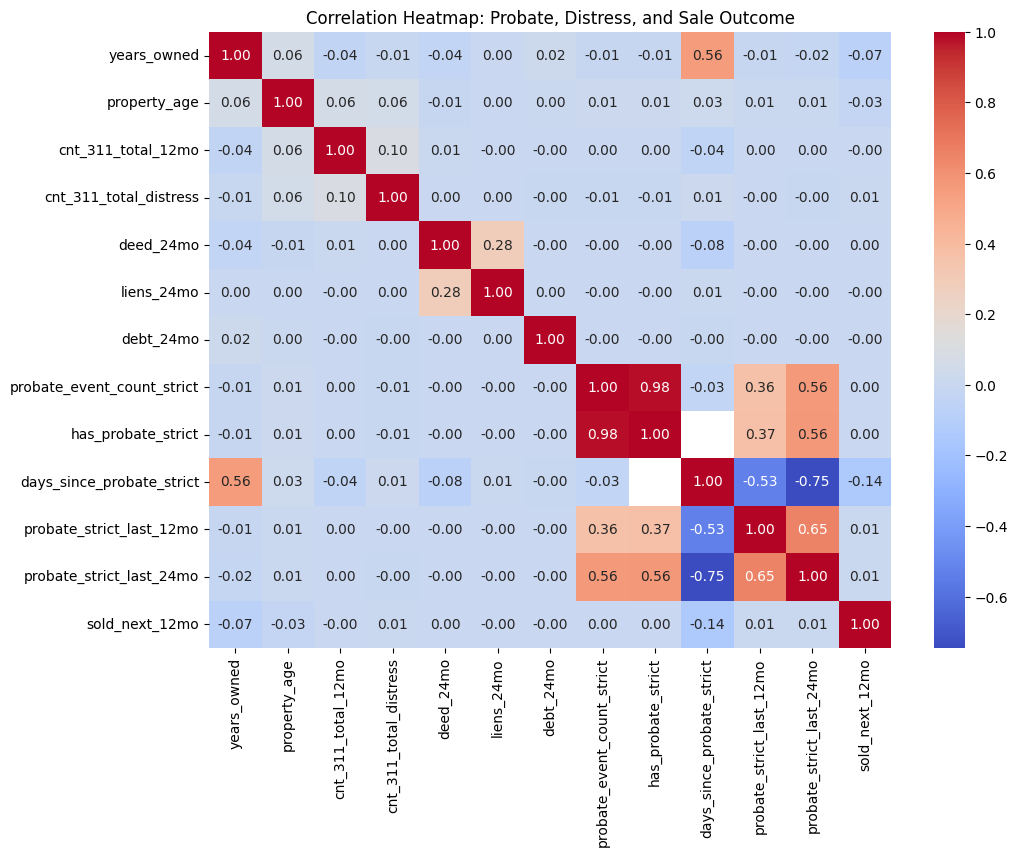

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

heatmap_cols = [
    'years_owned',
    'property_age',
    'cnt_311_total_12mo',
    'cnt_311_total_distress',
    'deed_24mo',
    'liens_24mo',
    'debt_24mo',
    'probate_event_count_strict',
    'has_probate_strict',
    'days_since_probate_strict',
    'probate_strict_last_12mo',
    'probate_strict_last_24mo',
    'sold_next_12mo'
]

corr = df[heatmap_cols].corr(numeric_only=True)

plt.figure(figsize=(11, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Heatmap: Probate, Distress, and Sale Outcome")
plt.show()

In [31]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np
from sklearn.metrics import mean_squared_error
# Select features
features = [
    'years_owned',
    'property_age',
    'deed_24mo',
    'liens_24mo',
    'debt_24mo',
    'months_since_last_civil',
    'probate_event_count_strict',
    'has_probate_strict'
]

# Drop missing
df_model = df[features + ['cnt_311_total_12mo']].dropna()

X = df_model[features]
y = df_model['cnt_311_total_12mo']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Fit model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Metrics
print("R2:", r2_score(y_test, y_pred))

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE:", rmse)

# Coefficients
coef_df = pd.DataFrame({
    'feature': X.columns,
    'coefficient': model.coef_
}).sort_values(by='coefficient', ascending=False)

print(coef_df)

R2: -0.0006701417507732899
RMSE: 1.2731292122022495
                      feature  coefficient
6  probate_event_count_strict     0.293275
7          has_probate_strict     0.293275
1                property_age     0.006533
5     months_since_last_civil     0.000997
0                 years_owned     0.000510
4                   debt_24mo    -0.003934
2                   deed_24mo    -0.024005
3                  liens_24mo    -0.102227


In [32]:
acct_series = df_modelacct['acct']

In [33]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    precision_recall_curve
)

# -------------------------
# 1. Base features
# -------------------------
base_features = [
    'years_owned',
    'property_age',
    'deed_24mo',
    'liens_24mo',
    'debt_24mo',
    'cnt_311_total_12mo',
    'months_since_last_civil',
    'probate_event_count_strict',
    'has_probate_strict',
    'probate_strict_last_12mo'
]

target = 'sold_next_12mo'

# -------------------------
# 2. Build modeling table
# -------------------------
df_model = df[base_features + [target]].copy()

# Fill missing values
df_model = df_model.fillna(0)

# -------------------------
# 3. Create interaction / helper features
# -------------------------
df_model['probate_x_311'] = (
    df_model['probate_strict_last_12mo'] * df_model['cnt_311_total_12mo']
)

df_model['probate_x_debt'] = (
    df_model['probate_strict_last_12mo'] * df_model['debt_24mo']
)

df_model['probate_x_liens'] = (
    df_model['probate_strict_last_12mo'] * df_model['liens_24mo']
)

df_model['recent_distress_flag'] = (
    (df_model['cnt_311_total_12mo'] > 0) |
    (df_model['debt_24mo'] > 0) |
    (df_model['liens_24mo'] > 0)
).astype(int)

# Optional: recode months_since_last_civil so "more recent civil" = bigger signal
# If 0 means very recent and large values mean older, this helps interpretation
max_civil = df_model['months_since_last_civil'].max()
df_model['civil_recency_score'] = (
    max_civil - df_model['months_since_last_civil']
)

# Replace original months feature with recency score if you want cleaner interpretation
features = [
    'years_owned',
    'property_age',
    'deed_24mo',
    'liens_24mo',
    'debt_24mo',
    'cnt_311_total_12mo',
    'probate_event_count_strict',
    'has_probate_strict',
    'probate_strict_last_12mo',
    'probate_x_311',
    'probate_x_debt',
    'probate_x_liens',
    'recent_distress_flag',
    'civil_recency_score'
]

X = df_model[features]
y = df_model[target]

# -------------------------
# 4. Train / test split
# -------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# -------------------------
# 5. Scale features
# -------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# -------------------------
# 6. Fit logistic regression
# -------------------------
model = LogisticRegression(
    max_iter=2000,
    class_weight='balanced',
    random_state=42
)

model.fit(X_train_scaled, y_train)

# -------------------------
# 7. Predicted probabilities
# -------------------------
y_prob = model.predict_proba(X_test_scaled)[:, 1]

# -------------------------
# 8. Find best threshold by F1
# -------------------------
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

# precision_recall_curve returns one extra precision/recall value
f1_scores = 2 * (precision[:-1] * recall[:-1]) / (precision[:-1] + recall[:-1] + 1e-9)

best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print("Best threshold by F1:", round(best_threshold, 4))
print("Best F1 from PR curve:", round(f1_scores[best_idx], 4))

# -------------------------
# 9. Evaluate at best threshold
# -------------------------
y_pred = (y_prob >= best_threshold).astype(int)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

print("AUC:", roc_auc_score(y_test, y_prob))
print("Precision:", precision_score(y_test, y_pred, zero_division=0))
print("Recall:", recall_score(y_test, y_pred, zero_division=0))
print("F1:", f1_score(y_test, y_pred, zero_division=0))

# -------------------------
# 10. Show threshold tradeoffs
# -------------------------
print("\nThreshold sweep:")
for t in [0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50]:
    y_pred_t = (y_prob >= t).astype(int)
    print(
        f"Threshold={t:.2f} | "
        f"Precision={precision_score(y_test, y_pred_t, zero_division=0):.4f} | "
        f"Recall={recall_score(y_test, y_pred_t, zero_division=0):.4f} | "
        f"F1={f1_score(y_test, y_pred_t, zero_division=0):.4f}"
    )

# -------------------------
# 11. Coefficients + odds ratios
# -------------------------
coef_df = pd.DataFrame({
    'feature': features,
    'coefficient': model.coef_[0]
})

coef_df['odds_ratio'] = np.exp(coef_df['coefficient'])
coef_df = coef_df.sort_values(by='coefficient', ascending=False)

print("\nLogistic Regression Coefficients / Odds Ratios:")
print(coef_df)

# -------------------------
# 12. Probability distribution check
# -------------------------
print("\nPredicted probability percentiles:")
print(pd.Series(y_prob).describe(percentiles=[0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]))

Best threshold by F1: 0.5331
Best F1 from PR curve: 0.1941

Confusion Matrix:
[[31463 15169]
 [ 2633  2144]]

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.67      0.78     46632
           1       0.12      0.45      0.19      4777

    accuracy                           0.65     51409
   macro avg       0.52      0.56      0.49     51409
weighted avg       0.85      0.65      0.73     51409

AUC: 0.5824681170493959
Precision: 0.12383757869808815
Recall: 0.44881724931965666
F1: 0.19411498415572656

Threshold sweep:
Threshold=0.10 | Precision=0.0929 | Recall=1.0000 | F1=0.1700
Threshold=0.15 | Precision=0.0929 | Recall=1.0000 | F1=0.1700
Threshold=0.20 | Precision=0.0929 | Recall=1.0000 | F1=0.1700
Threshold=0.25 | Precision=0.0929 | Recall=1.0000 | F1=0.1700
Threshold=0.30 | Precision=0.0930 | Recall=0.9990 | F1=0.1702
Threshold=0.35 | Precision=0.0942 | Recall=0.9805 | F1=0.1718
Threshold=0.40 | Precision=0.0971 | Recall=

The logistic regression model achieved modest predictive performance (AUC ≈ 0.58), indicating limited separability between properties that sell and those that do not. Predicted probabilities were tightly distributed between 0.40 and 0.60, suggesting that the available features provide weak individual signals. However, ownership duration emerged as a strong negative predictor, while probate and debt-related features showed modest positive influence. The model achieved a recall of approximately 45% at the optimal threshold, demonstrating practical utility for identifying potential sellers despite low precision.

In [34]:
df.groupby('probate_strict_last_24mo')['sold_next_6mo'].mean()

probate_strict_last_24mo
0    0.051854
1    0.094262
Name: sold_next_6mo, dtype: float64

Probate not out performing the opposite is likely due to most of them not related to a distressed sale:

estate planning transfers
trust movements
non-distressed inheritance
delayed/no-sale properties


In [35]:
target = 'sold_next_12mo'
features_numeric = [
    'years_owned',
    'building_area',
    'property_age',
    'deed_24mo',
    'liens_24mo',
    'debt_24mo',
    'cnt_311_total_12mo',
    'months_since_last_deed',
    'months_since_last_civil',
    'recent_civil',
    'recent_deed',
    'neighborhood_code',
    'probate_event_count_strict',
    'has_probate_strict',
    'days_since_probate_strict',
    'probate_strict_last_12mo',
    'probate_strict_last_24mo',
    'probate_strict_last_30mo',
    'probate_strict_last_36mo',
    'probate_strict_last_40mo',
]

features_categorical = []



In [36]:
# 1. Copy source
df_model = df.copy()

# 2. Apply square footage filter (RIGHT HERE)
df_model = df_model[
    (df_model["building_area"] > 900) &
    (df_model["building_area"] <= 4000)
].copy()

print("After sqft filter:", df_model.shape)

# 3. Select columns
cols_needed = features_numeric + features_categorical + [target]
df_model = df_model[cols_needed].copy()

print("After column selection:", df_model.shape)

After sqft filter: (238175, 33)
After column selection: (238175, 21)


In [37]:
#EDA begins below on engineered dataset

print("Shape:", df_model.shape)

na_summary = df_model.isna().sum().sort_values(ascending=False)

Shape: (238175, 21)


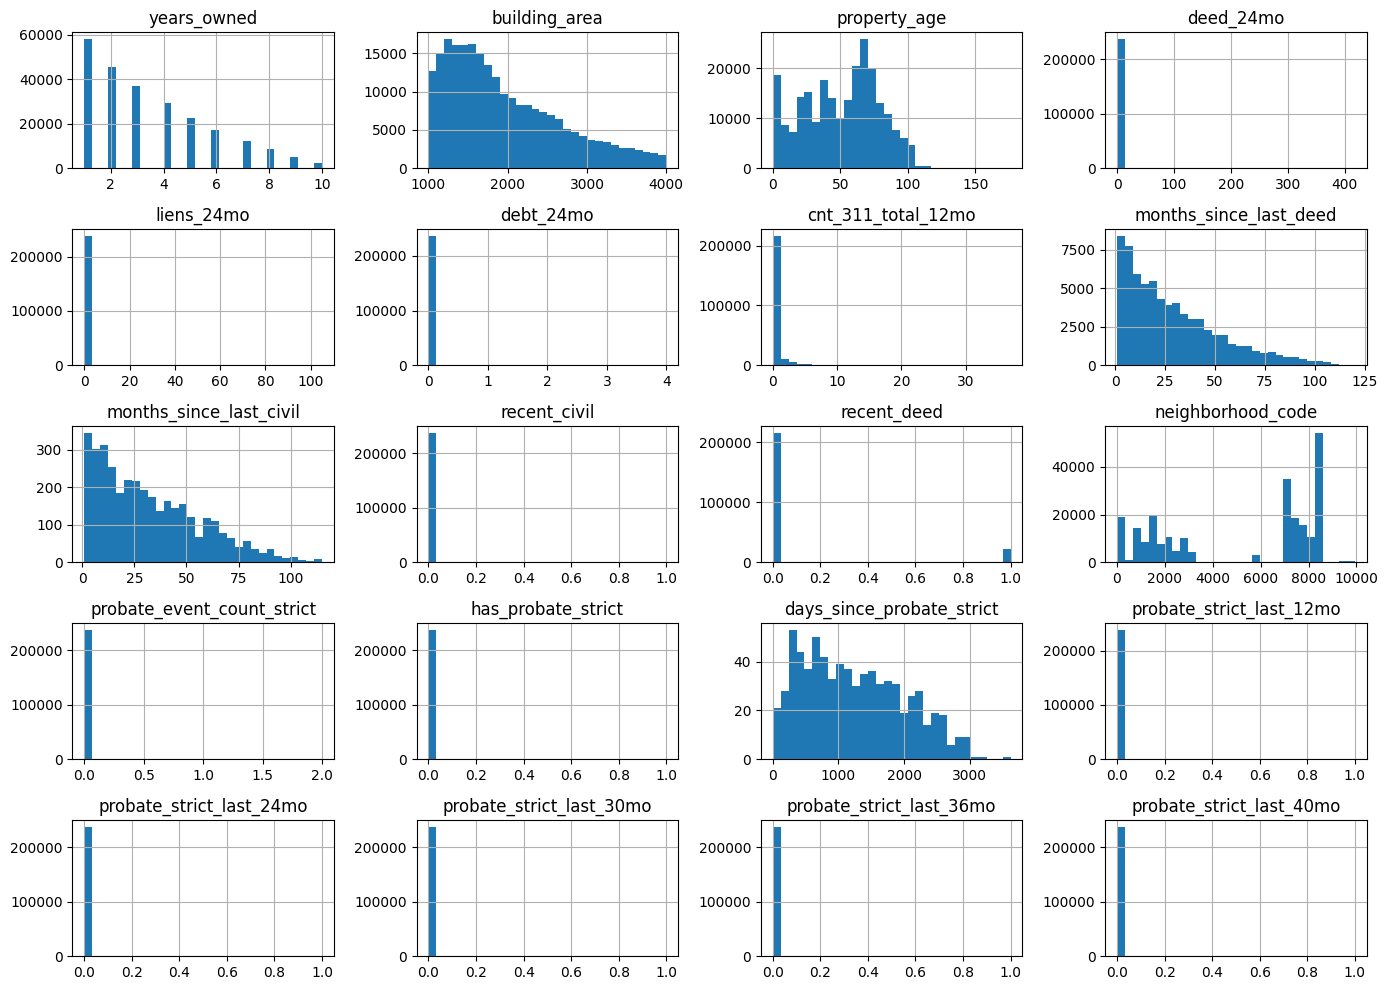

In [38]:
import matplotlib.pyplot as plt

X = df_model.drop(columns=[target])

X.hist(bins=30, figsize=(14,10))
plt.tight_layout()
plt.show()

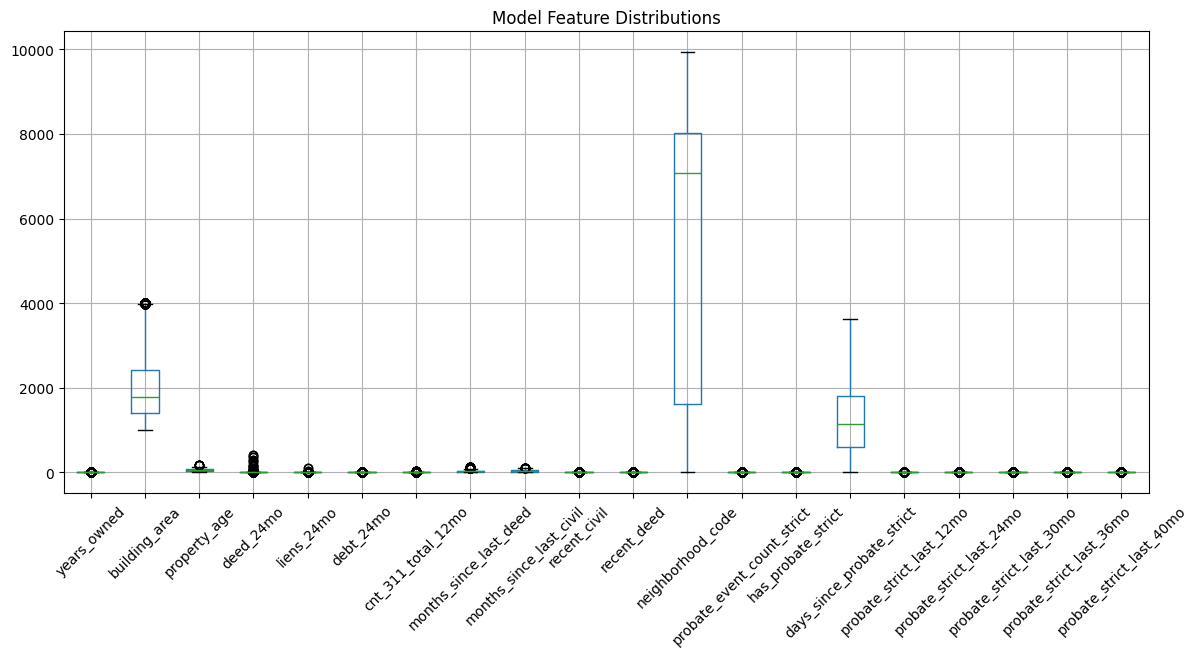

In [39]:
plt.figure(figsize=(14,6))
X.boxplot(rot=45)
plt.title("Model Feature Distributions")
plt.show()

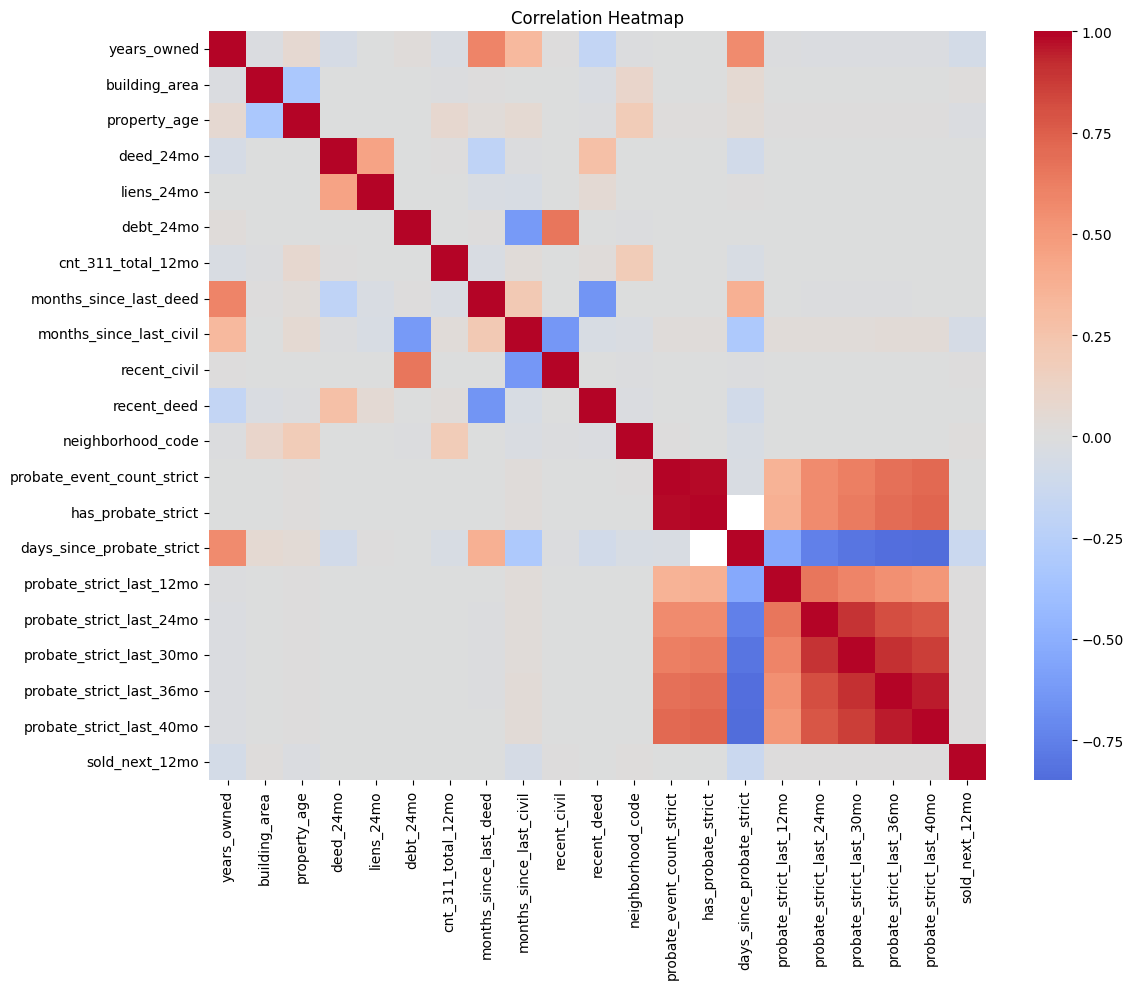

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure no duplicate columns
df_model = df_model.loc[:, ~df_model.columns.duplicated()]

# Select numeric only
corr_df = df_model.select_dtypes(include=['number', 'bool']).copy()

# Convert bool → int (vectorized)
bool_cols = corr_df.select_dtypes(include='bool').columns
corr_df[bool_cols] = corr_df[bool_cols].astype(int)

# Correlation
corr = corr_df.corr()

plt.figure(figsize=(12,10))
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

In [41]:
target = "sold_next_12mo"

X = df_model.drop(columns=[target])
y = df_model[target].astype(int)

print(X.shape)
print(y.shape)

(238175, 20)
(238175,)


In [42]:

# Define target
target = "sold_next_12mo"

# Combine features
final_features = features_numeric + features_categorical

# Remove duplicate columns
df_model = df_model.loc[:, ~df_model.columns.duplicated()]

# Keep only features that exist
valid_features = [c for c in final_features if c in df_model.columns]

# Build dataset
corr_df = df_model[valid_features + [target]].copy()

# Keep numeric only
corr_df = corr_df.select_dtypes(include=['number', 'bool'])

# Convert bool → int
bool_cols = corr_df.select_dtypes(include='bool').columns
corr_df[bool_cols] = corr_df[bool_cols].astype(int)

# Correlation vs target
corr_target = (
    corr_df.corr()[target]
    .sort_values(ascending=False)
)

print(corr_target.head(35))

sold_next_12mo                1.000000
building_area                 0.017220
neighborhood_code             0.011589
probate_strict_last_12mo      0.008120
probate_strict_last_24mo      0.006146
probate_strict_last_40mo      0.005499
probate_strict_last_36mo      0.005182
recent_civil                  0.005168
probate_strict_last_30mo      0.004577
has_probate_strict            0.000421
probate_event_count_strict    0.000407
debt_24mo                    -0.000106
liens_24mo                   -0.001124
deed_24mo                    -0.002208
cnt_311_total_12mo           -0.003553
months_since_last_deed       -0.009113
recent_deed                  -0.010698
property_age                 -0.024858
months_since_last_civil      -0.059752
years_owned                  -0.072445
days_since_probate_strict    -0.133761
Name: sold_next_12mo, dtype: float64


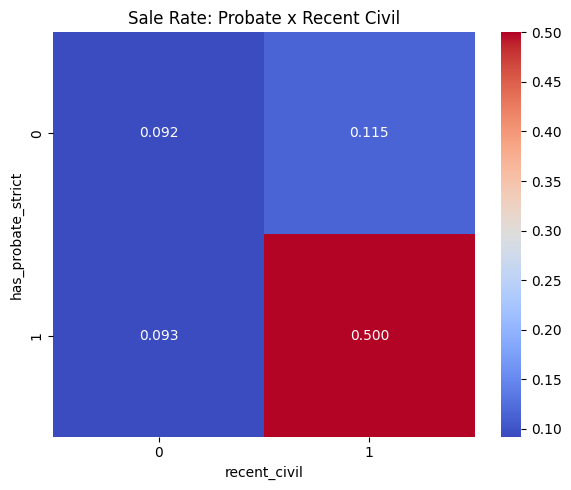

In [43]:
import seaborn as sns
import matplotlib.pyplot as plt

pivot = df_model.pivot_table(
    values='sold_next_12mo',
    index='has_probate_strict',
    columns='recent_civil',
    aggfunc='mean'
)

plt.figure(figsize=(6,5))
sns.heatmap(pivot, annot=True, cmap='coolwarm', fmt=".3f")
plt.title("Sale Rate: Probate x Recent Civil")
plt.tight_layout()
plt.show()

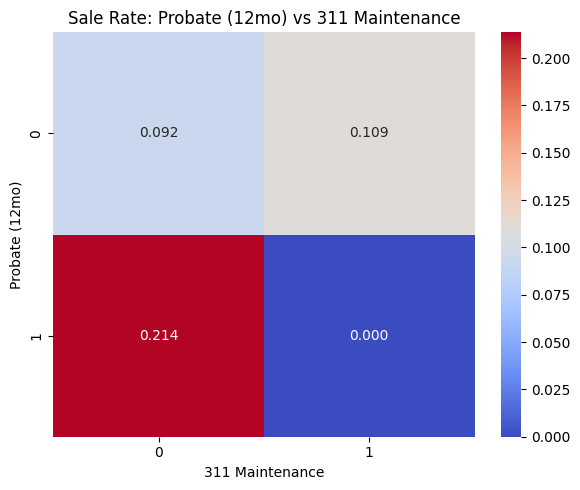

In [44]:
import seaborn as sns
import matplotlib.pyplot as plt

temp = df.copy()

# Create simple binary flags
temp["probate_flag"] = (temp["probate_strict_last_12mo"] == 1).astype(int)
temp["maint_flag"] = (temp["cnt_311_property_maintenance"] > 0).astype(int)

# Build pivot table
pivot = temp.pivot_table(
    values="sold_next_12mo",
    index="probate_flag",
    columns="maint_flag",
    aggfunc="mean"
)

# Plot
plt.figure(figsize=(6,5))
sns.heatmap(pivot, annot=True, cmap="coolwarm", fmt=".3f")

plt.title("Sale Rate: Probate (12mo) vs 311 Maintenance")
plt.xlabel("311 Maintenance")
plt.ylabel("Probate (12mo)")

plt.tight_layout()
plt.show()

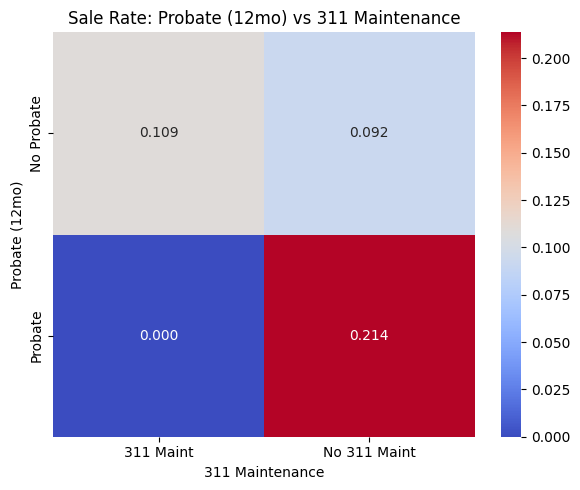

In [45]:
import seaborn as sns
import matplotlib.pyplot as plt

temp = df.copy()

# Binary flags
temp["probate_flag"] = (temp["probate_strict_last_12mo"] == 1).astype(int)
temp["maint_flag"] = (temp["cnt_311_property_maintenance"] > 0).astype(int)

# Optional: make labels readable
temp["probate_flag"] = temp["probate_flag"].map({0: "No Probate", 1: "Probate"})
temp["maint_flag"] = temp["maint_flag"].map({0: "No 311 Maint", 1: "311 Maint"})

# Pivot table
pivot = temp.pivot_table(
    values="sold_next_12mo",
    index="probate_flag",
    columns="maint_flag",
    aggfunc="mean"
)

# Plot
plt.figure(figsize=(6,5))
sns.heatmap(pivot, annot=True, cmap="coolwarm", fmt=".3f")

plt.title("Sale Rate: Probate (12mo) vs 311 Maintenance")
plt.xlabel("311 Maintenance")
plt.ylabel("Probate (12mo)")

plt.tight_layout()
plt.show()

In [46]:
df_model.head(2)

,years_owned,building_area,property_age,deed_24mo,liens_24mo,debt_24mo,cnt_311_total_12mo,months_since_last_deed,months_since_last_civil,recent_civil,recent_deed,neighborhood_code,probate_event_count_strict,has_probate_strict,days_since_probate_strict,probate_strict_last_12mo,probate_strict_last_24mo,probate_strict_last_30mo,probate_strict_last_36mo,probate_strict_last_40mo,sold_next_12mo
0,6,1435,54,0,0.0,0.0,0,<NA>,<NA>,0,0,793.0,0,0,<NA>,0,0,0,0,0,0
1,3,1203,57,0,0.0,0.0,0,39,<NA>,0,0,793.0,0,0,<NA>,0,0,0,0,0,0


In [47]:

df_model = df_model[
    (
        (df_model["cnt_311_total_12mo"] > 0) |
        (df_model["has_probate_strict"] == 1) |
        (df_model["debt_24mo"] > 0) |
        (df_model["liens_24mo"] > 0) |
        (df_model["probate_strict_last_12mo"] > 0) |
        (df_model["recent_civil"] == 1)
    ) &
    (df_model["property_age"] >= 10) &
    (df_model["years_owned"] >= 3) &
    (
        df_model["months_since_last_deed"].isna() |
        (df_model["months_since_last_deed"] >= 36)
    )
].copy()

# Start clean from filtered df_model
target = "sold_next_12mo"

# Make sure no duplicate columns
df_model = df_model.loc[:, ~df_model.columns.duplicated()].copy()

# Build X and y
X = df_model.drop(columns=[target])
y = df_model[target].astype(int)

# Final safety check: keep only numeric/bool columns
X = X.select_dtypes(include=["number", "bool"]).copy()

# Convert bools to ints
bool_cols = X.select_dtypes(include="bool").columns
X[bool_cols] = X[bool_cols].astype(int)

print(X.dtypes)
print(X.shape, y.shape)
print("Sale rate:", y.mean())

years_owned                     int64
building_area                   int64
property_age                    int64
deed_24mo                       int64
liens_24mo                    float64
debt_24mo                     float64
cnt_311_total_12mo              int64
months_since_last_deed          Int64
months_since_last_civil         Int64
recent_civil                    int64
recent_deed                     int64
neighborhood_code             float64
probate_event_count_strict      int64
has_probate_strict              int32
days_since_probate_strict       Int64
probate_strict_last_12mo        int32
probate_strict_last_24mo        int32
probate_strict_last_30mo        int32
probate_strict_last_36mo        int32
probate_strict_last_40mo        int32
dtype: object
(19631, 20) (19631,)
Sale rate: 0.0701950995873873


In [48]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [49]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    min_samples_split=5,
    min_samples_leaf=25,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,5
,min_samples_leaf,25
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [50]:
from sklearn.metrics import roc_auc_score, f1_score, classification_report

probs = rf.predict_proba(X_test)[:, 1]

threshold = 0.5
preds = (probs >= threshold).astype(int)

print("Threshold:", threshold)
print("AUC:", roc_auc_score(y_test, probs))
print("F1:", f1_score(y_test, preds))
print(classification_report(y_test, preds))

Threshold: 0.5
AUC: 0.5253881207848554
F1: 0.0
              precision    recall  f1-score   support

           0       0.93      1.00      0.96      3651
           1       0.00      0.00      0.00       276

    accuracy                           0.93      3927
   macro avg       0.46      0.50      0.48      3927
weighted avg       0.86      0.93      0.90      3927



c:\Users\howar\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\howar\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\howar\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

In [51]:
feat_imp = pd.DataFrame({
    "feature": X.columns,
    "importance": rf.feature_importances_
}).sort_values("importance", ascending=False)

print(feat_imp.head(25))

                       feature  importance
11           neighborhood_code    0.269171
1                building_area    0.244989
2                 property_age    0.192462
0                  years_owned    0.093959
7       months_since_last_deed    0.073627
6           cnt_311_total_12mo    0.059067
8      months_since_last_civil    0.041839
14   days_since_probate_strict    0.008771
5                    debt_24mo    0.006021
9                 recent_civil    0.005982
12  probate_event_count_strict    0.001234
18    probate_strict_last_36mo    0.001151
13          has_probate_strict    0.000962
19    probate_strict_last_40mo    0.000765
3                    deed_24mo    0.000000
4                   liens_24mo    0.000000
10                 recent_deed    0.000000
15    probate_strict_last_12mo    0.000000
17    probate_strict_last_30mo    0.000000
16    probate_strict_last_24mo    0.000000


In [52]:
#hyperparameter tuning
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
import numpy as np

rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

param_dist = {
    "n_estimators": [100, 200, 300, 400],
    "max_depth": [None, 10, 20, 30, 40],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 5, 10, 25],
    "max_features": ["sqrt", "log2", None],
    "bootstrap": [True, False]
}

rf_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=20,
    scoring="f1",
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

rf_search.fit(X_train, y_train)

print("Best Params:", rf_search.best_params_)
print("Best CV F1:", rf_search.best_score_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Params: {'n_estimators': 400, 'min_samples_split': 10, 'min_samples_leaf': 25, 'max_features': 'sqrt', 'max_depth': 10, 'bootstrap': False}
Best CV F1: 0.14858458811141081


In [53]:
#evaluate on test set
from sklearn.metrics import roc_auc_score, f1_score, classification_report

best_rf = rf_search.best_estimator_

probs = best_rf.predict_proba(X_test)[:, 1]
preds = (probs >= 0.5).astype(int)

print("Test AUC:", roc_auc_score(y_test, probs))
print("Test F1 @ 0.50:", f1_score(y_test, preds))
print(classification_report(y_test, preds))

Test AUC: 0.543849411914147
Test F1 @ 0.50: 0.1258426966292135
              precision    recall  f1-score   support

           0       0.93      0.62      0.74      3651
           1       0.07      0.41      0.13       276

    accuracy                           0.60      3927
   macro avg       0.50      0.51      0.43      3927
weighted avg       0.87      0.60      0.70      3927



In [54]:
#reoptimize after tuning
import numpy as np
from sklearn.metrics import f1_score

thresholds = np.linspace(0.05, 0.5, 30)

best_t = 0
best_f1 = 0

for t in thresholds:
    preds = (probs >= t).astype(int)
    f1 = f1_score(y_test, preds)
    if f1 > best_f1:
        best_f1 = f1
        best_t = t

print("Best threshold:", round(best_t, 3))
print("Best test F1:", round(best_f1, 4))

Best threshold: 0.469
Best test F1: 0.143


In [55]:
#final scores
final_preds = (probs >= best_t).astype(int)

print("Final AUC:", roc_auc_score(y_test, probs))
print("Final F1:", f1_score(y_test, final_preds))
print(classification_report(y_test, final_preds))

Final AUC: 0.543849411914147
Final F1: 0.14302103250478013
              precision    recall  f1-score   support

           0       0.94      0.41      0.57      3651
           1       0.08      0.68      0.14       276

    accuracy                           0.43      3927
   macro avg       0.51      0.54      0.36      3927
weighted avg       0.88      0.43      0.54      3927



In [56]:
#feature importance after tuning
import pandas as pd

feat_imp = pd.DataFrame({
    "feature": X.columns,
    "importance": best_rf.feature_importances_
}).sort_values("importance", ascending=False)

feat_imp.head(20)

,feature,importance
11,neighborhood_code,0.285162
1,building_area,0.213411
2,property_age,0.155572
0,years_owned,0.104526
7,months_since_last_deed,0.088745
6,cnt_311_total_12mo,0.057907
8,months_since_last_civil,0.053134
14,days_since_probate_strict,0.018899
5,debt_24mo,0.008169
9,recent_civil,0.008035


In [67]:
from IPython.display import display, HTML
#view properties with high scores
test_results = X_test.copy()

test_results["acct"] = acct_series.loc[X_test.index].values
test_results["actual"] = y_test.values
test_results["pred_prob"] = probs
test_results["pred_label"] = final_preds

test_results = test_results.sort_values("pred_prob", ascending=False)

test_results_filtered = test_results[
    test_results["probate_strict_last_12mo"] > 0
]

test_results_filtered.head(20)


,years_owned,building_area,property_age,deed_24mo,liens_24mo,debt_24mo,cnt_311_total_12mo,months_since_last_deed,months_since_last_civil,recent_civil,recent_deed,neighborhood_code,probate_event_count_strict,has_probate_strict,days_since_probate_strict,probate_strict_last_12mo,probate_strict_last_24mo,probate_strict_last_30mo,probate_strict_last_36mo,probate_strict_last_40mo,acct,actual,pred_prob,pred_label
50781,3,2068,41,0,0.0,0.0,2,<NA>,<NA>,0,0,8316.06,1,1,199,1,1,1,1,1,0571230010003,0,0.583099,1
9404,5,2242,19,0,0.0,0.0,0,<NA>,<NA>,0,0,8304.00,1,1,45,1,1,1,1,1,0201250000062,0,0.579101,1
205638,3,1782,35,0,0.0,0.0,0,<NA>,<NA>,0,0,7958.03,1,1,182,1,1,1,1,1,1127690000005,1,0.539769,1
130421,7,1162,62,0,0.0,0.0,0,<NA>,<NA>,0,0,1860.00,1,1,224,1,1,1,1,1,0934930000002,1,0.454716,0


In [71]:
from IPython.display import display, HTML

def scrollable_df(df, max_height="300px"):
    display(HTML(f"""
    <div style="max-height: {max_height}; overflow-y: auto; overflow-x: auto; border: 1px solid #ccc; padding: 4px;">
        {df.to_html(index=False)}
    </div>
    """))
# most recent snapshot per acct
latest_df = (
    df_modelacct
    .sort_values("snapshot_date")
    .groupby("acct", as_index=False)
    .tail(1)
    .copy()
)

# filter latest snapshots to distressed-only
latest_df = latest_df[
    (latest_df["cnt_311_total_12mo"] > 0) |
    (latest_df["has_probate_strict"] == 1) |
    (latest_df["debt_24mo"] > 0) |
    (latest_df["liens_24mo"] > 0) |
    (latest_df["probate_strict_last_12mo"] > 0) |
    (latest_df["recent_civil"] == 1)
].copy()

# same feature columns used by RF
rf_features = X_test.columns.tolist()

# scoring matrix
X_latest = latest_df[rf_features].copy()
X_latest = X_latest.fillna(0)

# score
latest_df["pred_prob"] = best_rf.predict_proba(X_latest)[:, 1]
latest_df["pred_label"] = best_rf.predict(X_latest)

# rank
latest_scored = latest_df.sort_values("pred_prob", ascending=False)

scrollable_df(latest_scored[
    ["acct", "snapshot_date", "pred_prob", "pred_label"] + rf_features
].head(500))



acct,snapshot_date,pred_prob,pred_label,years_owned,building_area,property_age,deed_24mo,liens_24mo,debt_24mo,cnt_311_total_12mo,months_since_last_deed,months_since_last_civil,recent_civil,recent_deed,neighborhood_code,probate_event_count_strict,has_probate_strict,days_since_probate_strict,probate_strict_last_12mo,probate_strict_last_24mo,probate_strict_last_30mo,probate_strict_last_36mo,probate_strict_last_40mo
0332270510006,2025-01-01,0.689428,1,3,1336,75,0,0.0,0.0,2,80,4,1,0,8410.01,0,0,<NA>,0,0,0,0,0
0611540000003,2025-01-01,0.676344,1,9,1798,97,0,0.0,0.0,6,103,4,1,0,8401.00,0,0,<NA>,0,0,0,0,0
0822220000017,2025-01-01,0.656573,1,5,1320,59,0,0.0,1.0,0,44,8,1,0,201.01,0,0,<NA>,0,0,0,0,0
0621350000008,2025-01-01,0.654408,1,4,1681,105,0,0.0,0.0,2,104,<NA>,0,0,8306.10,0,0,<NA>,0,0,0,0,0
0611630280017,2025-01-01,0.654153,1,8,2384,81,1,0.0,1.0,0,3,6,1,1,8401.00,0,0,<NA>,0,0,0,0,0
0180520000013,2025-01-01,0.646653,1,2,1807,95,0,0.0,0.0,1,91,<NA>,0,0,8316.00,0,0,<NA>,0,0,0,0,0
0552270100009,2025-01-01,0.646141,1,4,1148,65,0,0.0,3.0,0,40,1,1,0,1369.00,0,0,<NA>,0,0,0,0,0
0620890000006,2025-01-01,0.645237,1,3,1334,95,0,0.0,0.0,2,76,<NA>,0,0,8306.10,0,0,<NA>,0,0,0,0,0
0620600000014,2025-01-01,0.642737,1,3,3205,97,0,0.0,0.0,1,94,<NA>,0,0,8306.06,0,0,<NA>,0,0,0,0,0
0630750010019,2025-01-01,0.641829,1,3,2645,90,0,0.0,0.0,1,106,<NA>,0,0,8312.00,0,0,<NA>,0,0,0,0,0


In [59]:
from IPython.display import display, HTML

df = con.execute("""SHOW TABLES""").df()

display(HTML(f"""
<div style="max-height: 300px; overflow-y: auto; border: 1px solid #ccc;">
    {df.to_html(index=False)}
</div>
"""))

name
appraisals
civil_case_defendant_primary
civil_case_features
civil_case_owner_match
civil_case_property_clean
current_owner
deed_financial_events
deed_financial_events_raw
deed_financial_features
deed_financial_features_enhanced


In [60]:
con.execute("""
SELECT *
FROM model_features_rolling
WHERE acct = '0620600000014'
""").df()

,acct,snapshot_date,years_owned,sold_next_6mo,sold_next_12mo
0,0620600000014,2020-01-01,3,0,0
1,0620600000014,2018-01-01,1,0,0
2,0620600000014,2025-01-01,3,0,1
3,0620600000014,2023-01-01,1,0,0
4,0620600000014,2022-01-01,5,1,1
5,0620600000014,2024-01-01,2,0,0
6,0620600000014,2019-01-01,2,0,0
7,0620600000014,2021-01-01,4,0,0


In [75]:
latest_scored[latest_scored["acct"] == "0611540000003"]

,acct,snapshot_date,years_owned,sold_next_6mo,sold_next_12mo,sold_next_24mo,building_area,property_age,deed_24mo,liens_24mo,debt_24mo,cnt_311_total_12mo,months_since_last_deed,months_since_last_civil,debt_entity,cnt_311_property_maintenance,cnt_311_vehicle_issues,cnt_311_building_standards,cnt_311_nuisance,cnt_311_total_distress,recent_civil,recent_deed,neighborhood_code,probate_event_count_strict,has_probate_strict,first_probate_date_strict,last_probate_date_strict,days_since_probate_strict,probate_strict_last_12mo,probate_strict_last_24mo,probate_strict_last_30mo,probate_strict_last_36mo,probate_strict_last_40mo,pred_prob,pred_label
252710,0611540000003,2025-01-01,9,0,1,1,1798,97,0,0.0,0.0,6,103,4,0,0.0,0.0,0.0,0.0,0.0,1,0,8401.0,0,0,NaT,NaT,<NA>,0,0,0,0,0,0.676344,1
